In [4]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import norm


# Market and model inputs used in the checks below.
S0 = 100.0      # initial stock price
r = 0.03        # risk-free rate
q = 0.00        # dividend yield
T = 1.0         # time to maturity
K0 = 100.0      # strike price

heston_params = {
    "kappa": 2.0,   # variance mean-reversion speed
    "theta": 0.04,  # long-run variance
    "sigma": 0.30,  # volatility of variance
    "rho": -0.60,   # spot/variance correlation
    "v0": 0.04,     # initial variance
}


def black_scholes_call(S0, K, T, r, q, sigma):
    """
    Closed-form Black-Scholes call price.
    
    Inputs:
    S0      current stock price
    K       strike price (can be array-like)
    T       time to maturity
    r       risk-free rate
    q       dividend yield
    sigma   volatility
    """
    K = np.asarray(K, dtype=float)
    if T <= 0:
        return np.maximum(S0 - K, 0.0)
    vol_sqrt_T = sigma * np.sqrt(T)
    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / vol_sqrt_T
    d2 = d1 - vol_sqrt_T
    return S0 * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def heston_log_price_cf(u, S0, T, r, q, kappa, theta, sigma, rho, v0):
    """
    Characteristic function of log(S_T) under the risk-neutral Heston model.
    
    Inputs:
    u       complex argument (can be array-like)
    S0      current stock price
    T       time to maturity
    r       risk-free rate
    q       dividend yield
    kappa   variance mean-reversion speed
    theta   long-run variance
    sigma   volatility of variance
    rho     spot/variance correlation
    v0      initial variance
    """

    u = np.asarray(u, dtype=complex)
    x0 = np.log(S0)

    # With zero vol-of-vol, we expect variance to be deterministic and the CF be Black-Scholes-like.
    if abs(sigma) < 1e-14:      # Checks whether sigma(vol-of-vol) is basically zero. 
        if abs(kappa) < 1e-14:
            int_var = v0 * T
        else:
            int_var = theta * T + (v0 - theta) * (1.0 - np.exp(-kappa * T)) / kappa
        drift = x0 + (r - q) * T - 0.5 * int_var
        return np.exp(1j * u * drift - 0.5 * u**2 * int_var)

    iu = 1j * u
    a = kappa * theta
    b = kappa - rho * sigma * iu
    d = np.sqrt(b**2 + sigma**2 * (u**2 + iu))
    g = (b - d) / (b + d)
    exp_dt = np.exp(-d * T)

    # Little Heston Trap form keeps the complex logarithm numerically stable.
    C = iu * (x0 + (r - q) * T) + (a / sigma**2) * ((b - d) * T - 2.0 * np.log((1.0 - g * exp_dt) / (1.0 - g)))
    D = ((b - d) / sigma**2) * ((1.0 - exp_dt) / (1.0 - g * exp_dt))
    return np.exp(C + D * v0)


def carr_madan_fft_call_grid(S0, T, r, q, params, alpha=1.5, N=2**12, eta=0.25):
    """
    Price calls on a log-strike grid using the Carr-Madan damped FFT.
    
    Inputs:
    S0      current stock price
    T       time to maturity
    r       risk-free rate
    q       dividend yield
    params  Heston parameters: kappa, theta, sigma, rho, v0
    alpha   damping parameter
    N       number of FFT grid points
    eta     spacing in Fourier space
    """

    j = np.arange(N)        # frequency grid
    v = eta * j
    lam = 2.0 * np.pi / (N * eta)   # spacing in log-strike space
    b = 0.5 * N * lam   # half the width of the log-strike grid
    k = -b + lam * j    # creates the log-strike grid

    # Simpson weights improve the integral accuracy with the same FFT size.
    weights = np.ones(N)
    weights[0] = 1.0 / 3.0
    weights[1::2] = 4.0 / 3.0
    weights[2::2] = 2.0 / 3.0

    u = v - 1j * (alpha + 1.0)  # shifts the Fourier variable into the complex plane
    phi = heston_log_price_cf(u, S0, T, r, q, **params)     # evaluates the Heston characteristic function (at the shifted complex values)
    denominator = alpha**2 + alpha - v**2 + 1j * (2.0 * alpha + 1.0) * v
    psi = np.exp(-r * T) * phi / denominator

    # FFT evaluates the damped Fourier integral at all log-strikes at once.
    fft_input = np.exp(1j * b * v) * psi * eta * weights
    fft_values = np.fft.fft(fft_input).real     # runs FFT (Carr-Madan FFT call prices on the log-strike grid)
    strikes = np.exp(k)     # converts log-strikes into actual strikes
    calls = np.exp(-alpha * k) * fft_values / np.pi

    valid = np.isfinite(calls) & (calls > 0.0)
    return strikes[valid], calls[valid]


def carr_madan_fft_call(strikes, S0, T, r, q, params, alpha=1.5, N=2**12, eta=0.25):
    """Interpolate Carr-Madan FFT prices from the computed strike grid."""
    grid_K, grid_C = carr_madan_fft_call_grid(S0, T, r, q, params, alpha=alpha, N=N, eta=eta)
    f = interp1d(grid_K, grid_C, kind="cubic", bounds_error=False, fill_value="extrapolate")
    return np.asarray(f(strikes), dtype=float)


def heston_mc_call(S0, K, T, r, q, params, n_paths=120_000, n_steps=252, seed=7):
    """Monte Carlo Heston call using full-truncation Euler and antithetic normals."""
    rng = np.random.default_rng(seed)
    half_paths = n_paths // 2
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)

    log_S = np.full(n_paths, np.log(S0), dtype=float)
    v = np.full(n_paths, params["v0"], dtype=float)

    for _ in range(n_steps):
        z1_half = rng.standard_normal(half_paths)
        z2_half = rng.standard_normal(half_paths)
        z1 = np.concatenate([z1_half, -z1_half])
        z2 = np.concatenate([z2_half, -z2_half])
        zv = params["rho"] * z1 + np.sqrt(1.0 - params["rho"]**2) * z2

        v_pos = np.maximum(v, 0.0)
        log_S += (r - q - 0.5 * v_pos) * dt + np.sqrt(v_pos) * sqrt_dt * z1
        v += params["kappa"] * (params["theta"] - v_pos) * dt + params["sigma"] * np.sqrt(v_pos) * sqrt_dt * zv

    payoff = np.maximum(np.exp(log_S) - K, 0.0)
    discounted = np.exp(-r * T) * payoff
    price = discounted.mean()
    stderr = discounted.std(ddof=1) / np.sqrt(n_paths)
    return price, stderr


# Check 1: zero vol-of-vol with v0=theta reduces exactly to Black-Scholes.
bs_sigma = 0.20
bs_limit_params = {"kappa": 1.0, "theta": bs_sigma**2, "sigma": 0.0, "rho": 0.0, "v0": bs_sigma**2}
test_strikes = np.array([70, 80, 90, 100, 110, 120, 130], dtype=float)
fft_bs = carr_madan_fft_call(test_strikes, S0, T, r, q, bs_limit_params, N=2**13, eta=0.15)
closed_bs = black_scholes_call(S0, test_strikes, T, r, q, bs_sigma)
bs_errors = np.abs(fft_bs - closed_bs)

print("Black-Scholes collapse check")
for K, fft_price, bs_price, err in zip(test_strikes, fft_bs, closed_bs, bs_errors):
    print(f"K={K:6.1f}  FFT={fft_price:10.6f}  BS={bs_price:10.6f}  abs_err={err:.2e}")
print(f"max_abs_err={bs_errors.max():.2e}\n")

# Check 2: compare one Heston FFT price with a Monte Carlo confidence interval.
fft_heston = carr_madan_fft_call(np.array([K0]), S0, T, r, q, heston_params, N=2**13, eta=0.15)[0]
mc_heston, mc_se = heston_mc_call(S0, K0, T, r, q, heston_params)
mc_low, mc_high = mc_heston - 1.96 * mc_se, mc_heston + 1.96 * mc_se

print("Heston FFT vs Monte Carlo check")
print(f"FFT price       = {fft_heston:.6f}")
print(f"MC price        = {mc_heston:.6f}")
print(f"MC 95% interval = [{mc_low:.6f}, {mc_high:.6f}]")
print(f"abs_diff        = {abs(fft_heston - mc_heston):.6f}")

assert bs_errors.max() < 1e-3, "FFT should collapse to Black-Scholes in the zero vol-of-vol limit."
assert mc_low <= fft_heston <= mc_high, "FFT price should fall inside the Monte Carlo 95% interval."


Black-Scholes collapse check
K=  70.0  FFT= 32.235176  BS= 32.235176  abs_err=2.88e-10
K=  80.0  FFT= 23.223991  BS= 23.223991  abs_err=2.97e-12
K=  90.0  FFT= 15.429227  BS= 15.429227  abs_err=7.13e-11
K= 100.0  FFT=  9.413403  BS=  9.413403  abs_err=7.10e-09
K= 110.0  FFT=  5.293398  BS=  5.293398  abs_err=2.49e-09
K= 120.0  FFT=  2.766558  BS=  2.766558  abs_err=1.74e-09
K= 130.0  FFT=  1.357670  BS=  1.357670  abs_err=3.30e-10
max_abs_err=7.10e-09

Heston FFT vs Monte Carlo check
FFT price       = 9.244531
MC price        = 9.215855
MC 95% interval = [9.148174, 9.283536]
abs_diff        = 0.028676


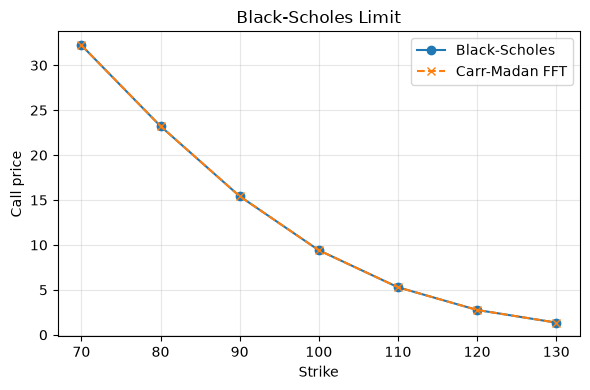

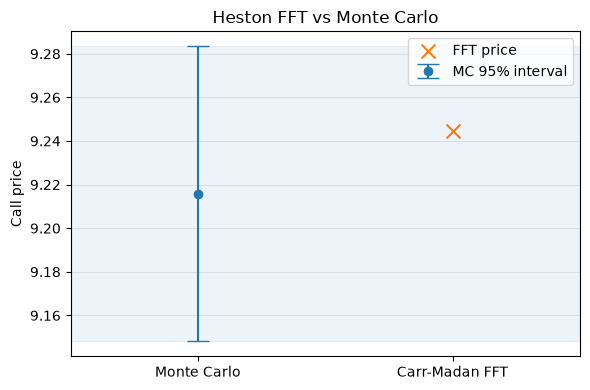

In [5]:
import matplotlib.pyplot as plt


# Check 1: FFT prices overlap the Black-Scholes benchmark.
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(test_strikes, closed_bs, "o-", label="Black-Scholes")
ax.plot(test_strikes, fft_bs, "x--", label="Carr-Madan FFT")
ax.set_title("Black-Scholes Limit")
ax.set_xlabel("Strike")
ax.set_ylabel("Call price")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Check 2: FFT price lies inside the Monte Carlo 95% interval.
fig, ax = plt.subplots(figsize=(6, 4))
mc_error = 1.96 * mc_se
x_pos = [0.25, 0.75]

ax.errorbar([x_pos[0]], [mc_heston], yerr=[mc_error], fmt="o", capsize=8, label="MC 95% interval")
ax.scatter([x_pos[1]], [fft_heston], marker="x", s=100, color="tab:orange", label="FFT price")
ax.axhspan(mc_low, mc_high, color="tab:blue", alpha=0.08)
ax.set_xlim(0.0, 1.0)
ax.set_xticks(x_pos)
ax.set_xticklabels(["Monte Carlo", "Carr-Madan FFT"])
ax.set_title("Heston FFT vs Monte Carlo")
ax.set_ylabel("Call price")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
